# Table of Contents
* [Import Libraries](#Import-Libraries)
* [Exploration](#Exploration)
* [Correlation Matrix of the numerical features](#Correlation-Matrix-of-the-numerical-features)
* [Data Pre-Processing](#Data-Preprocessing)
* [Heatmap](#Heatmap)
* [Standartization](#Standartization)
* [Dealing With Outliers](#Dealing-With-Outliers)
* [Modeling](#Modeling)
* [Best Model-Random Forest](#Best-Model-Random-Forest)
* [PCA](#PCA)
* [Back To Pre-proccessing](#Back-To-Pre-proccessing)
* [Conclusion](#Conclusion)

# Import Libraries

In [65]:
!pip install pandas


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [66]:
!pip install scikit-learn
!pip install plotly 
!pip install imbalanced-learn


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [67]:
!pip install seaborn


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [68]:
!pip install plotly


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [69]:
!pip install imblearn


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [70]:
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.offline as pyo
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import MinMaxScaler
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
%matplotlib inline

# Exploration

In [71]:
df = pd.read_csv('transaction_dataset.csv')
pd.set_option('display.max_columns', None)
df.head()

,Unnamed: 0,Index,Address,FLAG,Avg min between sent tnx,Avg min between received tnx,Time Diff between first and last (Mins),Sent tnx,Received Tnx,Number of Created Contracts,Unique Received From Addresses,Unique Sent To Addresses,min value received,max value received,avg val received,min val sent,max val sent,avg val sent,min value sent to contract,max val sent to contract,avg value sent to contract,total transactions (including tnx to create contract,total Ether sent,total ether received,total ether sent contracts,total ether balance,Total ERC20 tnxs,ERC20 total Ether received,ERC20 total ether sent,ERC20 total Ether sent contract,ERC20 uniq sent addr,ERC20 uniq rec addr,ERC20 uniq sent addr.1,ERC20 uniq rec contract addr,ERC20 avg time between sent tnx,ERC20 avg time between rec tnx,ERC20 avg time between rec 2 tnx,ERC20 avg time between contract tnx,ERC20 min val rec,ERC20 max val rec,ERC20 avg val rec,ERC20 min val sent,ERC20 max val sent,ERC20 avg val sent,ERC20 min val sent contract,ERC20 max val sent contract,ERC20 avg val sent contract,ERC20 uniq sent token name,ERC20 uniq rec token name,ERC20 most sent token type,ERC20_most_rec_token_type
0,0,1,0x00009277775ac7d0d59eaad8fee3d10ac6c805e8,0,844.26,1093.71,704785.63,721,89,0,40,118,0.000000,45.806785,6.589513,0.00,31.220000,1.200681,0.0,0.0,0.0,810,865.691093,586.466675,0.0,-279.224419,265.0,3.558854e+07,3.560317e+07,0.0,30.0,54.0,0.0,58.0,0.0,0.0,0.0,0.0,0.0,1.500000e+07,265586.147600,0.000000,1.683100e+07,271779.920000,0.0,0.0,0.0,39.0,57.0,Cofoundit,Numeraire
1,1,2,0x0002b44ddb1476db43c868bd494422ee4c136fed,0,12709.07,2958.44,1218216.73,94,8,0,5,14,0.000000,2.613269,0.385685,0.00,1.800000,0.032844,0.0,0.0,0.0,102,3.087297,3.085478,0.0,-0.001819,8.0,4.034283e+02,2.260809e+00,0.0,1.0,5.0,0.0,7.0,0.0,0.0,0.0,0.0,0.0,3.650000e+02,57.632615,2.260809,2.260809e+00,2.260809,0.0,0.0,0.0,1.0,7.0,Livepeer Token,Livepeer Token
2,2,3,0x0002bda54cb772d040f779e88eb453cac0daa244,0,246194.54,2434.02,516729.30,2,10,0,10,2,0.113119,1.165453,0.358906,0.05,3.538616,1.794308,0.0,0.0,0.0,12,3.588616,3.589057,0.0,0.000441,8.0,5.215121e+02,0.000000e+00,0.0,0.0,7.0,0.0,8.0,0.0,0.0,0.0,0.0,0.0,4.428198e+02,65.189009,0.000000,0.000000e+00,0.000000,0.0,0.0,0.0,0.0,8.0,NaN,XENON
3,3,4,0x00038e6ba2fd5c09aedb96697c8d7b8fa6632e5e,0,10219.60,15785.09,397555.90,25,9,0,7,13,0.000000,500.000000,99.488840,0.00,450.000000,70.001834,0.0,0.0,0.0,34,1750.045862,895.399559,0.0,-854.646303,14.0,1.711105e+04,1.141223e+04,0.0,2.0,11.0,0.0,11.0,0.0,0.0,0.0,0.0,0.0,1.141223e+04,1555.550174,100.000000,9.029231e+03,3804.076893,0.0,0.0,0.0,1.0,11.0,Raiden,XENON
4,4,5,0x00062d1dd1afb6fb02540ddad9cdebfe568e0d89,0,36.61,10707.77,382472.42,4598,20,1,7,19,0.000000,12.802411,2.671095,0.00,9.000000,0.022688,0.0,0.0,0.0,4619,104.318883,53.421897,0.0,-50.896986,42.0,1.628297e+05,1.235399e+05,0.0,4.0,23.0,0.0,27.0,0.0,0.0,0.0,0.0,0.0,9.000000e+04,4934.232147,0.000000,4.500000e+04,13726.659220,0.0,0.0,0.0,6.0,27.0,StatusNetwork,EOS


In [72]:
df.drop(['Unnamed: 0','Index','Address'],axis =1,inplace = True)
df.head()

,FLAG,Avg min between sent tnx,Avg min between received tnx,Time Diff between first and last (Mins),Sent tnx,Received Tnx,Number of Created Contracts,Unique Received From Addresses,Unique Sent To Addresses,min value received,max value received,avg val received,min val sent,max val sent,avg val sent,min value sent to contract,max val sent to contract,avg value sent to contract,total transactions (including tnx to create contract,total Ether sent,total ether received,total ether sent contracts,total ether balance,Total ERC20 tnxs,ERC20 total Ether received,ERC20 total ether sent,ERC20 total Ether sent contract,ERC20 uniq sent addr,ERC20 uniq rec addr,ERC20 uniq sent addr.1,ERC20 uniq rec contract addr,ERC20 avg time between sent tnx,ERC20 avg time between rec tnx,ERC20 avg time between rec 2 tnx,ERC20 avg time between contract tnx,ERC20 min val rec,ERC20 max val rec,ERC20 avg val rec,ERC20 min val sent,ERC20 max val sent,ERC20 avg val sent,ERC20 min val sent contract,ERC20 max val sent contract,ERC20 avg val sent contract,ERC20 uniq sent token name,ERC20 uniq rec token name,ERC20 most sent token type,ERC20_most_rec_token_type
0,0,844.26,1093.71,704785.63,721,89,0,40,118,0.000000,45.806785,6.589513,0.00,31.220000,1.200681,0.0,0.0,0.0,810,865.691093,586.466675,0.0,-279.224419,265.0,3.558854e+07,3.560317e+07,0.0,30.0,54.0,0.0,58.0,0.0,0.0,0.0,0.0,0.0,1.500000e+07,265586.147600,0.000000,1.683100e+07,271779.920000,0.0,0.0,0.0,39.0,57.0,Cofoundit,Numeraire
1,0,12709.07,2958.44,1218216.73,94,8,0,5,14,0.000000,2.613269,0.385685,0.00,1.800000,0.032844,0.0,0.0,0.0,102,3.087297,3.085478,0.0,-0.001819,8.0,4.034283e+02,2.260809e+00,0.0,1.0,5.0,0.0,7.0,0.0,0.0,0.0,0.0,0.0,3.650000e+02,57.632615,2.260809,2.260809e+00,2.260809,0.0,0.0,0.0,1.0,7.0,Livepeer Token,Livepeer Token
2,0,246194.54,2434.02,516729.30,2,10,0,10,2,0.113119,1.165453,0.358906,0.05,3.538616,1.794308,0.0,0.0,0.0,12,3.588616,3.589057,0.0,0.000441,8.0,5.215121e+02,0.000000e+00,0.0,0.0,7.0,0.0,8.0,0.0,0.0,0.0,0.0,0.0,4.428198e+02,65.189009,0.000000,0.000000e+00,0.000000,0.0,0.0,0.0,0.0,8.0,NaN,XENON
3,0,10219.60,15785.09,397555.90,25,9,0,7,13,0.000000,500.000000,99.488840,0.00,450.000000,70.001834,0.0,0.0,0.0,34,1750.045862,895.399559,0.0,-854.646303,14.0,1.711105e+04,1.141223e+04,0.0,2.0,11.0,0.0,11.0,0.0,0.0,0.0,0.0,0.0,1.141223e+04,1555.550174,100.000000,9.029231e+03,3804.076893,0.0,0.0,0.0,1.0,11.0,Raiden,XENON
4,0,36.61,10707.77,382472.42,4598,20,1,7,19,0.000000,12.802411,2.671095,0.00,9.000000,0.022688,0.0,0.0,0.0,4619,104.318883,53.421897,0.0,-50.896986,42.0,1.628297e+05,1.235399e+05,0.0,4.0,23.0,0.0,27.0,0.0,0.0,0.0,0.0,0.0,9.000000e+04,4934.232147,0.000000,4.500000e+04,13726.659220,0.0,0.0,0.0,6.0,27.0,StatusNetwork,EOS


In [73]:
# Output the count of each label
print("Counts of each label:\n", df['FLAG'].value_counts())

# Check for rows with undetermined fraud status
print("Number of rows with undetermined fraud status:", df['FLAG'].isnull().sum())

Counts of each label:
 FLAG
0    7662
1    2179
Name: count, dtype: int64
Number of rows with undetermined fraud status: 0


In [74]:
df.shape

(9841, 48)

#### We can see that the data is imbalanced, and it's something important we should consider later when modeling

In [75]:
# Important information about each feature
df.describe()

,FLAG,Avg min between sent tnx,Avg min between received tnx,Time Diff between first and last (Mins),Sent tnx,Received Tnx,Number of Created Contracts,Unique Received From Addresses,Unique Sent To Addresses,min value received,max value received,avg val received,min val sent,max val sent,avg val sent,min value sent to contract,max val sent to contract,avg value sent to contract,total transactions (including tnx to create contract,total Ether sent,total ether received,total ether sent contracts,total ether balance,Total ERC20 tnxs,ERC20 total Ether received,ERC20 total ether sent,ERC20 total Ether sent contract,ERC20 uniq sent addr,ERC20 uniq rec addr,ERC20 uniq sent addr.1,ERC20 uniq rec contract addr,ERC20 avg time between sent tnx,ERC20 avg time between rec tnx,ERC20 avg time between rec 2 tnx,ERC20 avg time between contract tnx,ERC20 min val rec,ERC20 max val rec,ERC20 avg val rec,ERC20 min val sent,ERC20 max val sent,ERC20 avg val sent,ERC20 min val sent contract,ERC20 max val sent contract,ERC20 avg val sent contract,ERC20 uniq sent token name,ERC20 uniq rec token name
count,9841.000000,9841.000000,9841.000000,9.841000e+03,9841.000000,9841.000000,9841.000000,9841.000000,9841.000000,9841.000000,9841.000000,9841.000000,9841.000000,9841.000000,9841.000000,9841.000000,9841.000000,9841.000000,9841.000000,9.841000e+03,9.841000e+03,9841.000000,9.841000e+03,9012.000000,9.012000e+03,9.012000e+03,9012.000000,9012.000000,9012.000000,9012.000000,9012.000000,9012.0,9012.0,9012.0,9012.0,9012.000000,9.012000e+03,9.012000e+03,9.012000e+03,9.012000e+03,9.012000e+03,9012.0,9012.0,9012.0,9012.000000,9012.000000
mean,0.221421,5086.878721,8004.851184,2.183333e+05,115.931714,163.700945,3.729702,30.360939,25.840159,43.845153,523.152481,100.711721,4.800090,314.617297,44.755731,0.000003,0.000008,0.000005,283.362362,1.016092e+04,1.163832e+04,0.000008,1.477395e+03,36.255659,1.296207e+08,1.386849e+07,110.939207,5.638038,7.598535,0.003440,4.901909,0.0,0.0,0.0,0.0,485.614688,1.252524e+08,4.346203e+06,1.174126e+04,1.303594e+07,6.318389e+06,0.0,0.0,0.0,1.384931,4.826676
std,0.415224,21486.549974,23081.714801,3.229379e+05,757.226361,940.836550,141.445583,298.621112,263.820410,325.929139,13008.821539,2885.002236,138.609682,6629.212643,239.080215,0.000225,0.000516,0.000323,1352.404013,3.583227e+05,3.642048e+05,0.000516,2.424254e+05,447.528908,1.053858e+10,1.180390e+09,6128.634953,105.252500,81.818470,0.065698,17.246576,0.0,0.0,0.0,0.0,16883.278712,1.053741e+10,2.141192e+08,1.053567e+06,1.179905e+09,5.914764e+08,0.0,0.0,0.0,6.735121,16.678607
min,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000,-1.560535e+07,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.0,0.0,0.0,0.000000,0.000000
25%,0.000000,0.000000,0.000000,3.169300e+02,1.000000,1.000000,0.000000,1.000000,1.000000,0.001000,1.000000,0.426905,0.000000,0.164577,0.086184,0.000000,0.000000,0.000000,4.000000,2.262059e-01,2.670424e+00,0.000000,6.214900e-04,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.0,0.0,0.0,0.000000,0.000000
50%,0.000000,17.340000,509.770000,4.663703e+04,3.000000,4.000000,0.000000,2.000000,2.000000,0.095856,6.000000,1.729730,0.049126,4.999380,1.606000,0.000000,0.000000,0.000000,8.000000,1.248680e+01,3.052963e+01,0.000000,1.722000e-03,1.000000,1.000000e-12,0.000000e+00,0.000000,0.000000,1.000000,0.000000,1.000000,0.0,0.0,0.0,0.0,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.0,0.0,0.0,0.000000,1.000000
75%,0.000000,565.470000,5480.390000,3.040710e+05,11.000000,27.000000,0.000000,5.000000,3.000000,2.000000,67.067040,22.000000,0.998800,61.520653,21.999380,0.000

#### We learned a lot from the std describing for each feature, there are few features that all of their values are around the value of 0 ,so we may not use them when modeling

In [76]:
# Output the number of null values for each feature, only showing features with nulls
print("Number of null values per feature:")
print(df.isnull().sum()[df.isnull().sum() > 0])
print()

# Output the number of unique values for two specific categorical features
print("Number of unique values for feature 'ERC20_most_rec_token_type':", df[' ERC20_most_rec_token_type'].nunique())
print("Number of unique values for feature 'ERC20 most sent token type':", df[' ERC20 most sent token type'].nunique())

Number of null values per feature:
Total ERC20 tnxs                        829
ERC20 total Ether received              829
ERC20 total ether sent                  829
ERC20 total Ether sent contract         829
ERC20 uniq sent addr                    829
ERC20 uniq rec addr                     829
ERC20 uniq sent addr.1                  829
ERC20 uniq rec contract addr            829
ERC20 avg time between sent tnx         829
ERC20 avg time between rec tnx          829
ERC20 avg time between rec 2 tnx        829
ERC20 avg time between contract tnx     829
ERC20 min val rec                       829
ERC20 max val rec                       829
ERC20 avg val rec                       829
ERC20 min val sent                      829
ERC20 max val sent                      829
ERC20 avg val sent                      829
ERC20 min val sent contract             829
ERC20 max val sent contract             829
ERC20 avg val sent contract             829
ERC20 uniq sent token name              8

In [77]:
# Find duplicate rows
duplicate_rows = df[df.duplicated()]
duplicate_rows

,FLAG,Avg min between sent tnx,Avg min between received tnx,Time Diff between first and last (Mins),Sent tnx,Received Tnx,Number of Created Contracts,Unique Received From Addresses,Unique Sent To Addresses,min value received,max value received,avg val received,min val sent,max val sent,avg val sent,min value sent to contract,max val sent to contract,avg value sent to contract,total transactions (including tnx to create contract,total Ether sent,total ether received,total ether sent contracts,total ether balance,Total ERC20 tnxs,ERC20 total Ether received,ERC20 total ether sent,ERC20 total Ether sent contract,ERC20 uniq sent addr,ERC20 uniq rec addr,ERC20 uniq sent addr.1,ERC20 uniq rec contract addr,ERC20 avg time between sent tnx,ERC20 avg time between rec tnx,ERC20 avg time between rec 2 tnx,ERC20 avg time between contract tnx,ERC20 min val rec,ERC20 max val rec,ERC20 avg val rec,ERC20 min val sent,ERC20 max val sent,ERC20 avg val sent,ERC20 min val sent contract,ERC20 max val sent contract,ERC20 avg val sent contract,ERC20 uniq sent token name,ERC20 uniq rec token name,ERC20 most sent token type,ERC20_most_rec_token_type
2933,0,5980.35,18633.46,498256.47,21,20,0,2,18,1.990000,499.990000,129.970060,0.000669,499.989580,123.780506,0.0,0.0,0.0,41,2599.390622,2599.401197,0.0,0.010575,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0,0
2934,0,7042.64,2694.86,80594.87,8,9,0,8,7,0.001000,2.812069,0.880369,0.000000,2.060330,0.989884,0.0,0.0,0.0,17,7.919068,7.923318,0.0,0.004250,3.0,140.401861,140.102687,0.0,1.0,2.0,0.0,2.0,0.0,0.0,0.0,0.0,0.299173,140.102687,70.200930,140.102687,140.102687,140.102687,0.0,0.0,0.0,1.0,2.0,Golem,OmiseGO
2936,0,0.00,0.00,0.00,0,1,0,1,0,0.250303,0.250303,0.250303,0.000000,0.000000,0.000000,0.0,0.0,0.0,1,0.000000,0.250303,0.0,0.250303,5.0,72.218973,0.000000,0.0,0.0,5.0,0.0,5.0,0.0,0.0,0.0,0.0,0.000000,64.921895,14.443795,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,5.0,NaN,Livepeer Token
2937,0,0.00,0.00,0.00,0,1,0,1,0,0.804725,0.804725,0.804725,0.000000,0.000000,0.000000,0.0,0.0,0.0,1,0.000000,0.804725,0.0,0.804725,5.0,190.055731,0.000000,0.0,0.0,5.0,0.0,5.0,0.0,0.0,0.0,0.0,0.000000,171.588208,38.011146,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,5.0,NaN,Livepeer Token
2939,0,9695.78,1133.48,257022.97,14,107,0,6,1,1.027784,278.228000,62.635543,0.008543,2582.449433,478.714007,0.0,0.0,0.0,121,6701.996102,6702.003081,0.0,0.006979,1.0,600.000000,0.000000,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,600.000000,600.000000,600.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,1.0,NaN,AICRYPTO
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9814,1,0.00,0.00,0.00,0,0,0,0,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0,0.000000,0.000000,0.0,0.000000,1.0,1.337000,0.000000,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.337000,1.337000,1.337000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,1.0,,Blockwell say NOTSAFU
9818,1,0.00,0.00,0.00,0,0,0,0,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0,0.000000,0.000000,0.0,0.000000,1.0,13.370000,0.000000,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,13.370000,13.370000,13.370000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,1.0,,Blockwell say NOTSAFU
9823,1,0.00,0.00,0.00,0,0,1,0,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,1,0.000000,0.000000,0.0,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9833,1,0.00,0.00,0.00,0,0,0,0,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0,0.000000,0.000000,0.0,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [78]:
# Remove duplicate rows
df.drop_duplicates(inplace=True)

# Rename feature columns by stripping leading/trailing spaces
df_copy = df.copy()
df_copy.columns = df_copy.columns.str.strip()

# Impute missing values for numerical features with mean
for col in df_copy.columns:
    if df_copy[col].isnull().sum() == 829:
        df_copy[col].fillna(df_copy[col].mean(), inplace=True)

# Output columns that still have missing values
print("Columns still with missing values:")
print(df_copy.isnull().sum()[df_copy.isnull().sum() > 0])
print()

# Check value counts of a categorical feature
categorical_feature = 'ERC20_most_rec_token_type'
print(f"Value counts of feature '{categorical_feature}':\n{df_copy[categorical_feature].value_counts()}")

Columns still with missing values:
Total ERC20 tnxs                        549
ERC20 total Ether received              549
ERC20 total ether sent                  549
ERC20 total Ether sent contract         549
ERC20 uniq sent addr                    549
ERC20 uniq rec addr                     549
ERC20 uniq sent addr.1                  549
ERC20 uniq rec contract addr            549
ERC20 avg time between sent tnx         549
ERC20 avg time between rec tnx          549
ERC20 avg time between rec 2 tnx        549
ERC20 avg time between contract tnx     549
ERC20 min val rec                       549
ERC20 max val rec                       549
ERC20 avg val rec                       549
ERC20 min val sent                      549
ERC20 max val sent                      549
ERC20 avg val sent                      549
ERC20 min val sent contract             549
ERC20 max val sent contract             549
ERC20 avg val sent contract             549
ERC20 uniq sent token name              5

In [79]:
# Clean categorical features - replace '0' with null because '0' has no meaning in categorical features
categorical_features = ['ERC20_most_rec_token_type', 'ERC20 most sent token type']
df_copy[categorical_features] = df_copy[categorical_features].replace({'0': np.nan})

# Output the processed features
print("Processed features:")
print(df_copy[categorical_features])

Processed features:
             ERC20_most_rec_token_type ERC20 most sent token type
0                            Numeraire                  Cofoundit
1                       Livepeer Token             Livepeer Token
2                                XENON                        NaN
3                                XENON                     Raiden
4                                  EOS              StatusNetwork
...                                ...                        ...
9835                               NaN                        NaN
9836                        GSENetwork                           
9838  Free BOB Tokens - BobsRepair.com                           
9839                               NaN                        NaN
9840                        INS Promo1                           

[9295 rows x 2 columns]


In [80]:
# Check the null value percentage for a specific feature
null_percentage = df_copy['ERC20 most sent token type'].isnull().sum() / len(df_copy)
print("Null percentage for feature 'ERC20 most sent token type':", null_percentage)

Null percentage for feature 'ERC20 most sent token type': 0.7312533620225928


In [81]:
# Create a list of features with non-zero variance
to_drop = list(df_copy.var(numeric_only=True)[df_copy.var(numeric_only=True) == 0].keys())
print("List of features with non-zero variance:", to_drop)

# Drop features with non-zero variance
df_copy.drop(to_drop, inplace=True, axis=1)
print("Data description after dropping features with non-zero variance:")
print(df_copy.describe())

# Find features with standard deviation close to 0
low_std_features = list(df_copy.std(numeric_only=True)[df_copy.std(numeric_only=True) < 0.001].keys())
print("List of features with standard deviation close to 0:", low_std_features)

List of features with non-zero variance: ['ERC20 avg time between sent tnx', 'ERC20 avg time between rec tnx', 'ERC20 avg time between rec 2 tnx', 'ERC20 avg time between contract tnx', 'ERC20 min val sent contract', 'ERC20 max val sent contract', 'ERC20 avg val sent contract']
Data description after dropping features with non-zero variance:
              FLAG  Avg min between sent tnx  Avg min between received tnx  \
count  9295.000000               9295.000000                   9295.000000   
mean      0.178160               5381.861541                   8466.699446   
std       0.382668              22072.588325                  23662.864816   
min       0.000000                  0.000000                      0.000000   
25%       0.000000                  0.000000                      0.030000   
50%       0.000000                 21.710000                    803.550000   
75%       0.000000                839.760000                   6050.335000   
max       1.000000             4

In [82]:
df_copy.drop(['min value sent to contract','max val sent to contract','avg value sent to contract'\
              ,'total ether sent contracts']\
             ,axis =1 , inplace = True)

In [83]:
# Fill missing values of categorical features with mode
df_copy = df_copy.fillna(df_copy.mode().iloc[0])

# Output columns that still have missing values
remaining_nulls = df_copy.isnull().sum()[df_copy.isnull().sum() > 0]
print("Columns still with missing values:")
print(remaining_nulls)

Columns still with missing values:
Series([], dtype: int64)


In [84]:
df_copy[['ERC20_most_rec_token_type', 'ERC20 most sent token type']].columns

Index(['ERC20_most_rec_token_type', 'ERC20 most sent token type'], dtype='object')

In [85]:
# Code to process features with more than 50 categories (unique values)
# In this process, we will use Label Encoding for features with more than 50 categories

# Create a copy for processing
df_encoded = df_copy.copy()

# Store features that need Label Encoding
label_encoding_features = []

# Store categorical features and their mapping dictionaries
categorical_features_dict = {}

# Iterate over the features to be processed
for feature in df_copy[['ERC20_most_rec_token_type', 'ERC20 most sent token type']].columns:
    if df_copy[feature].nunique() >= 50:  # If more than 50 unique categories, we will use Label Encoding
        label_encoding_features.append(feature)
        categorical_features_dict[feature] = {}  # Dictionary will store original values as keys and sequential numbers (categories) as values
        i = 1  # Sequential number (category)
        
        # Map feature values to categories using dictionary
        for sample in df_copy[feature]:
            if sample not in categorical_features_dict[feature].keys() and sample is not np.nan:  # We replace each value (not 'null') with dictionary mapping
                categorical_features_dict[feature][sample] = i
                i += 1

        # Apply Label Encoding using the mapping dictionary on the copy and original data
        df_encoded[feature].replace(categorical_features_dict[feature], inplace=True)

# Output the features requiring Label Encoding and the mapping dictionaries
print("Features requiring Label Encoding:", label_encoding_features)
print("Mapping dictionaries for categorical features:", categorical_features_dict)

C:\Users\lenovo\AppData\Local\Temp\ipykernel_15588\3107109915.py:27: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_encoded[feature].replace(categorical_features_dict[feature], inplace=True)
C:\Users\lenovo\AppData\Local\Temp\ipykernel_15588\3107109915.py:27: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', T

Features requiring Label Encoding: ['ERC20_most_rec_token_type', 'ERC20 most sent token type']
Mapping dictionaries for categorical features: {'ERC20_most_rec_token_type': {'Numeraire': 1, 'Livepeer Token': 2, 'XENON': 3, 'EOS': 4, 'OmiseGO': 5, 'AICRYPTO': 6, 'DATAcoin': 7, 'PoSToken': 8, 'KyberNetwork': 9, 'Bancor': 10, 'ONOT': 11, 'Tronix': 12, 'StatusNetwork': 13, 'SAFE.AD - 20% DISCOUNT UNTIL 1 MAY': 14, 'Storj': 15, 'bitqy': 16, 'Beauty Coin': 17, 'SONM': 18, 'NEVERDIE': 19, 'INS Promo': 20, 'TenXPay': 21, 'Cybereits Token': 22, 'FunFair': 23, 'DGD': 24, 'iEx.ec Network Token': 25, 'AION': 26, 'Aragon': 27, 'Cofoundit': 28, 'Golem': 29, 'CRYPTOPUNKS': 30, 'Nitro': 31, 'Ether Token': 32, 'VeChain': 33, 'Reputation': 34, 'Intelion': 35, 'Dochain': 36, 'SwarmCity': 37, 'BAT': 38, 'LockTrip': 39, 'Humaniq': 40, 'KickCoin': 41, 'BOX Token': 42, 'MobileGo': 43, 'Monaco': 44, 'Azbit': 45, 'Nexium': 46, 'ZGC': 47, 'www.pnztrust.com': 48, 'Send your ETH to this contract and earn 2.55% eve

In [86]:
from sklearn.ensemble import IsolationForest
from sklearn.decomposition import PCA

# Perform Principal Component Analysis
pca = PCA(n_components=0.95)  # Retain 95% of variance
X_pca = pca.fit_transform(df_encoded.drop('FLAG', axis=1))

# Create Isolation Forest model
isolation_forest_model = IsolationForest(contamination=0.05, random_state=42)

# Train the model and predict outliers
isolation_forest_preds = isolation_forest_model.fit_predict(X_pca)

# Identify outliers
outliers_isolation_forest = isolation_forest_preds == -1

# Remove outliers identified by Isolation Forest from the original data
df_encoded_cleaned = df_encoded[~outliers_isolation_forest]

# Output statistical information of the data after outlier removal
print("Statistical information after outlier removal:")
print(df_encoded_cleaned.describe())

Statistical information after outlier removal:
              FLAG  Avg min between sent tnx  Avg min between received tnx  \
count  8830.000000               8830.000000                   8830.000000   
mean      0.182333               5372.405237                   8635.850299   
std       0.386141              22511.520915                  24194.740474   
min       0.000000                  0.000000                      0.000000   
25%       0.000000                  0.000000                      0.000000   
50%       0.000000                 18.770000                    666.750000   
75%       0.000000                457.290000                   6027.695000   
max       1.000000             430287.670000                 482175.490000   

       Time Diff between first and last (Mins)      Sent tnx  Received Tnx  \
count                             8.830000e+03   8830.000000   8830.000000   
mean                              2.066364e+05     82.078143    137.970328   
std             

# Correlation Matrix of the numerical features

In [87]:
# Assume df_copy is the DataFrame containing the data
df_pca_cleaned_isolation = df_encoded_cleaned
# Keep the 'FLAG' column, perform PCA on other features
features_to_pca = df_pca_cleaned_isolation.drop('FLAG', axis=1)

# Standardize the data
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features_to_pca)

# Use PCA for dimensionality reduction
pca = PCA(n_components=0.95)  # Retain 95% of variance
features_pca = pca.fit_transform(features_scaled)

# Convert the reduced data back to DataFrame and add the 'FLAG' column
df_pca = pd.DataFrame(data=features_pca, columns=['PC{}'.format(i) for i in range(1, pca.n_components_ + 1)])
df_pca['FLAG'] = df_copy['FLAG']

# Output the DataFrame after dimensionality reduction
print(df_pca)

           PC1       PC2       PC3       PC4       PC5       PC6       PC7  \
0     1.004162 -0.097451 -0.569128  0.071117 -0.030694 -0.638465 -0.885005   
1     1.104471 -0.081828 -1.204663  0.139555 -0.098832 -0.522601 -1.525271   
2     1.406223 -0.106620 -0.841776  0.057820 -0.212505  0.068153 -0.492720   
3     9.429552 -0.679747 -0.133864 -0.803650 -0.818214 -0.744022  0.681379   
4    -0.872356  0.025877  0.030759 -0.099458  0.189138 -0.065388  0.181284   
...        ...       ...       ...       ...       ...       ...       ...   
8825 -0.909020  0.028135  0.055362 -0.110408  0.214040 -0.062064  0.228784   
8826 -0.303209 -0.006223 -0.168694  0.052768  0.197091 -0.224861 -0.101831   
8827  0.217490 -0.043865 -0.183951  0.040287  0.110172 -0.276865 -0.245738   
8828 -0.916908  0.028760  0.054962 -0.108300  0.209157 -0.058053  0.231269   
8829  6.784575 -0.525923 -0.415541  1.319155 -4.139640  9.349794 -3.400366   

           PC8       PC9      PC10      PC11      PC12      PC1

In [88]:
# Calculate the correlation coefficients between features
corr = df_pca.corr()

# Filter features with relatively high correlation based on correlation coefficient
corr_df = corr[(corr > 0.6)].dropna(axis=1, thresh=2)
corr_df = corr_df[corr_df != 1]

# Find features with correlation exceeding 0.9
to_drop = corr_df[corr_df > 0.9]
high_corr_features = to_drop.values[to_drop.values > 0]

# Find features to drop
to_drop_features = to_drop.unstack().sort_values(kind="quicksort")[to_drop.unstack() > 0]

print("List of features to drop:")
print(to_drop_features)

List of features to drop:
Series([], dtype: float64)


In [89]:
# Check the correlation between features and the label, sort in descending order
correlation_with_label = df_pca.corr()['FLAG'].sort_values(ascending=False)

# Output the correlation between features and the label
print("Correlation between features and the label:")
print(correlation_with_label)

Correlation between features and the label:
FLAG    1.000000
PC12    0.334985
PC13    0.089933
PC2     0.063234
PC5     0.021004
PC18    0.014449
PC7     0.006702
PC4     0.003588
PC20    0.000075
PC21   -0.008017
PC6    -0.010505
PC15   -0.016887
PC8    -0.020286
PC11   -0.025690
PC3    -0.032879
PC1    -0.040564
PC17   -0.051131
PC9    -0.071167
PC19   -0.090166
PC14   -0.149933
PC10   -0.173712
PC16   -0.196301
Name: FLAG, dtype: float64


# Heatmap

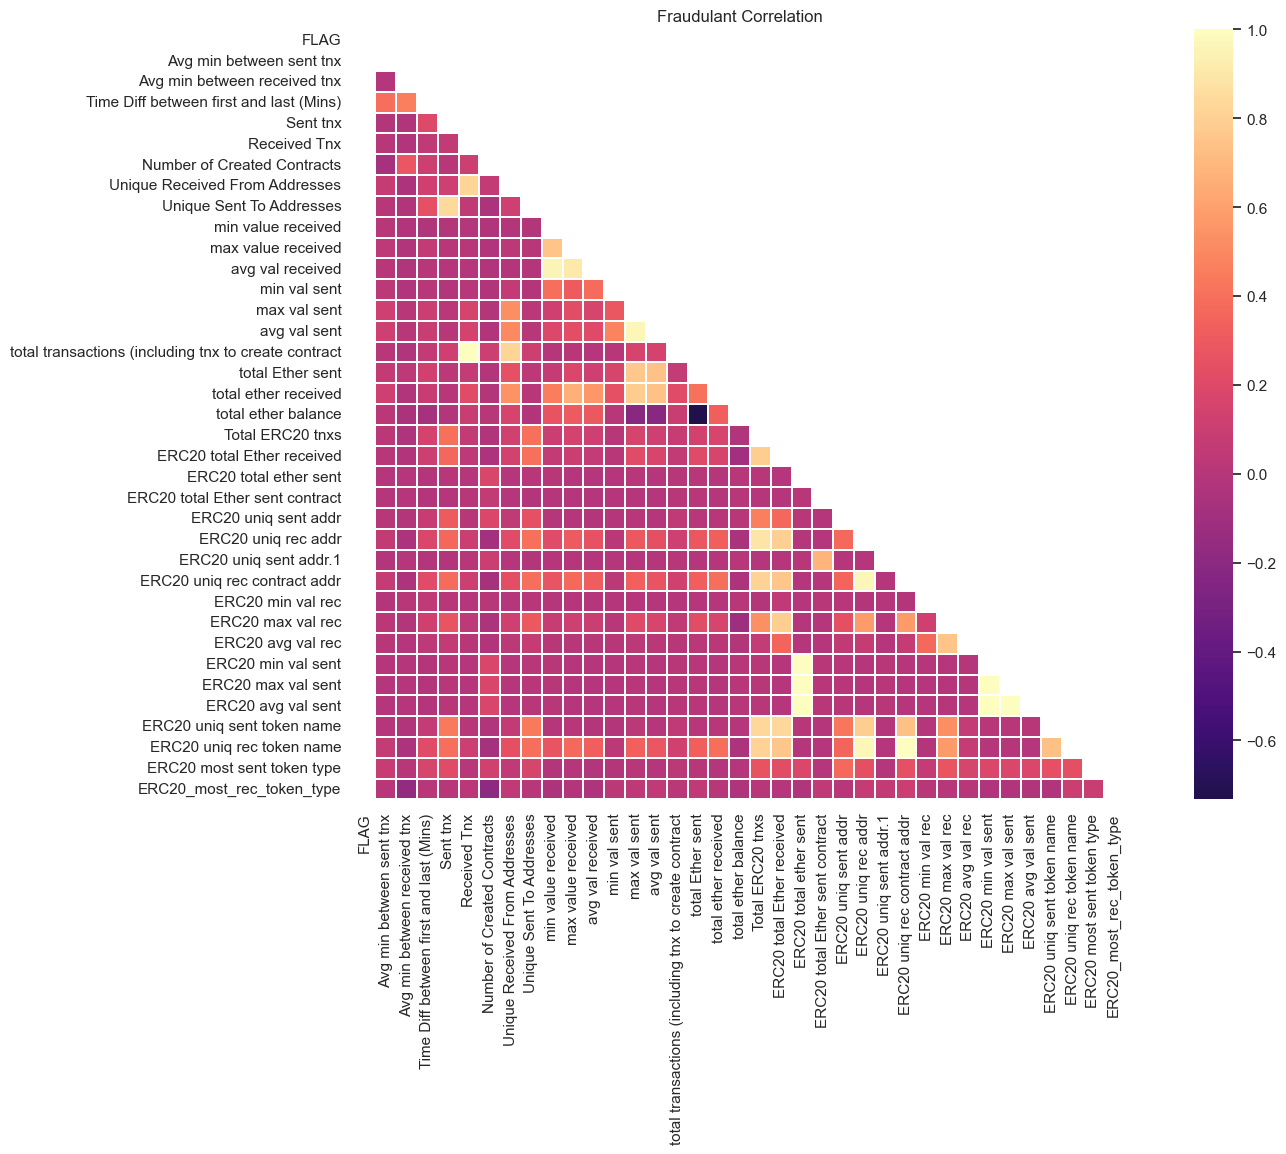

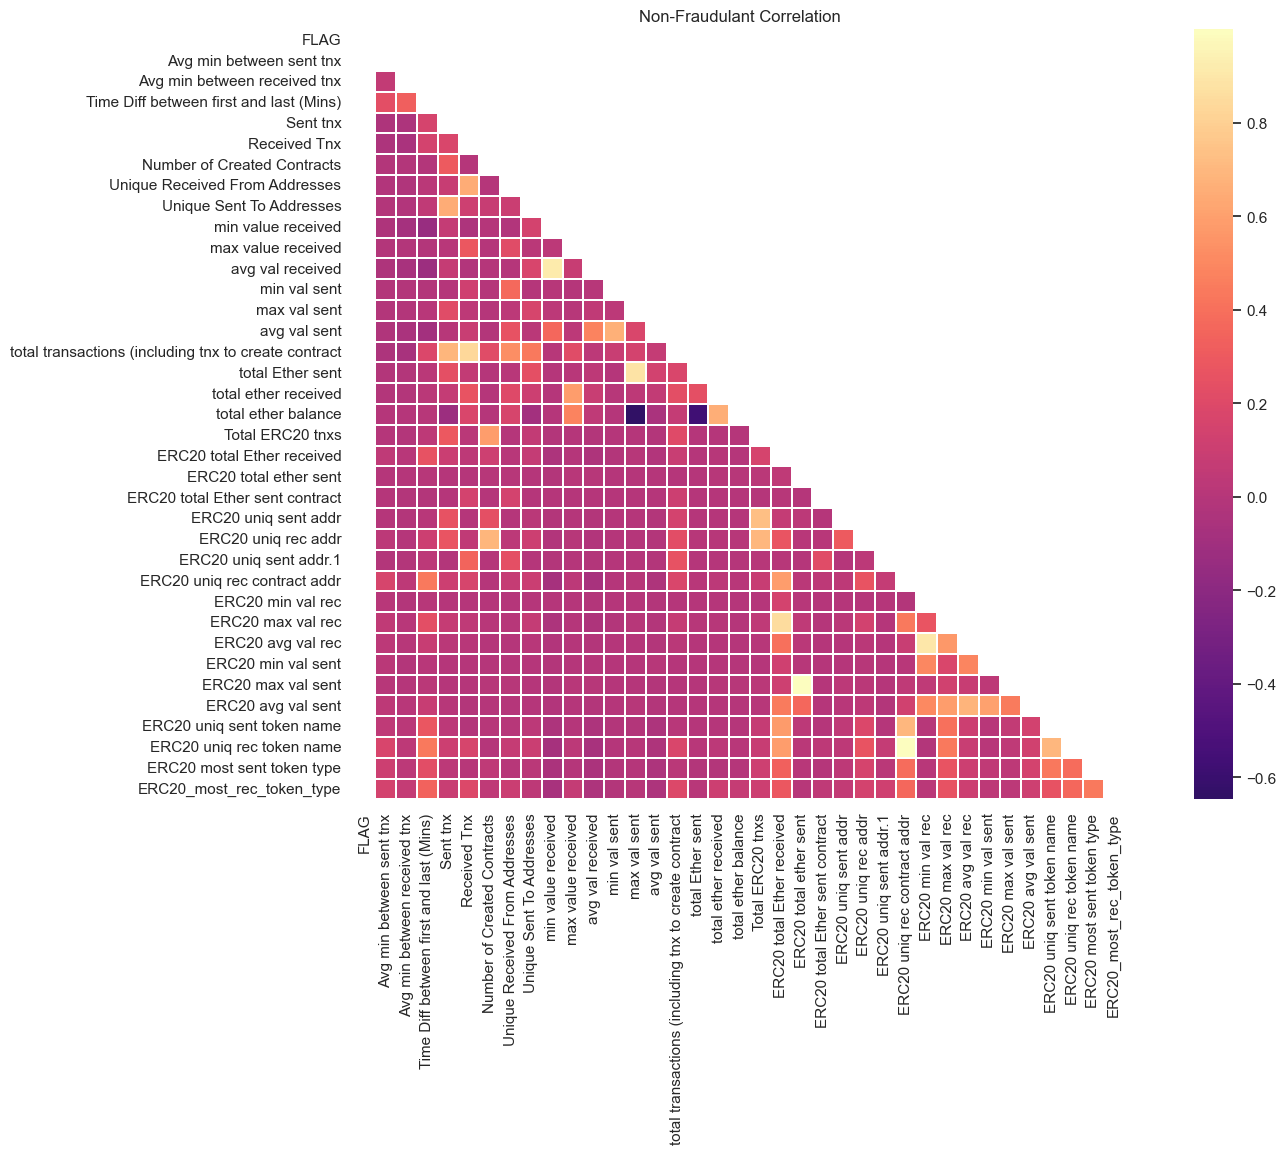

In [90]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# For better readability and understanding, we can split the code into two functions
def plot_correlation_heatmap(data, title):
    corr = data.corr()
    mask = np.zeros_like(corr)
    mask[np.triu_indices_from(mask)] = True
    with sns.axes_style('white'):
        fig, ax = plt.subplots(figsize=(18, 10))
        sns.heatmap(corr, mask=mask, annot=False, cmap='magma', center=0, linewidths=0.1, square=True)
        plt.title(title)
        plt.show()

# Plot the correlation matrices for fraud and non-fraud samples separately
fraud_sample = df_encoded_cleaned[df_encoded_cleaned['FLAG'] == 1]
non_fraud_sample = df_encoded_cleaned[df_encoded_cleaned['FLAG'] == 0]

plot_correlation_heatmap(fraud_sample, 'Fraudulant Correlation')
plot_correlation_heatmap(non_fraud_sample, 'Non-Fraudulant Correlation')

# Dealing With Outliers

#### as we saw at the table represent the correlation to the label, the below feature is the most correlated to the label
#### we will try to find outliers from visualizing the relatioinship between this feature and the label

In [91]:
# Find some outliers in the previously plotted scatter plot
# Next, we will check whether removing these outliers improves our model results
outliers_indices = df_copy[(df_copy['Received Tnx'] > 3000) & (df_copy['FLAG'] == 1) & (df_copy['Received Tnx'] < 4000)].index

# Output the indices of the outliers found
print("Indices of outliers found:")
print(outliers_indices)

Indices of outliers found:
Index([8408, 9219, 9322], dtype='int64')


### we want found some strong outliers for the fraud transactions, we will try to find them and drop these rows

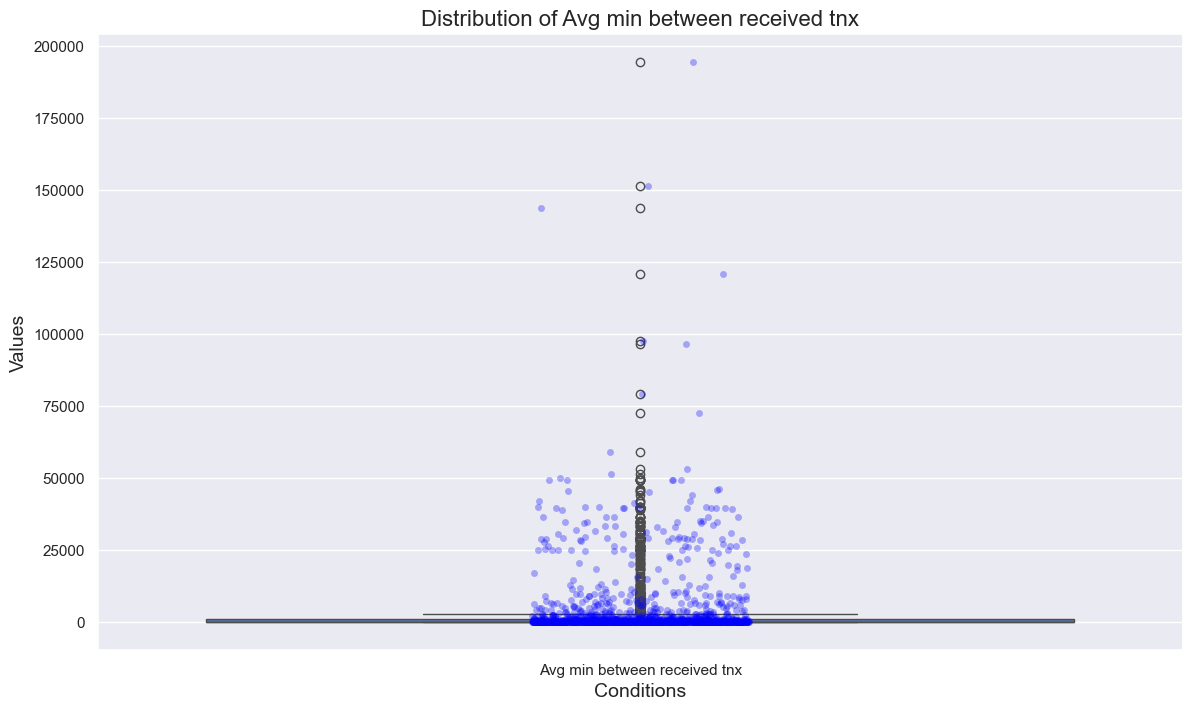

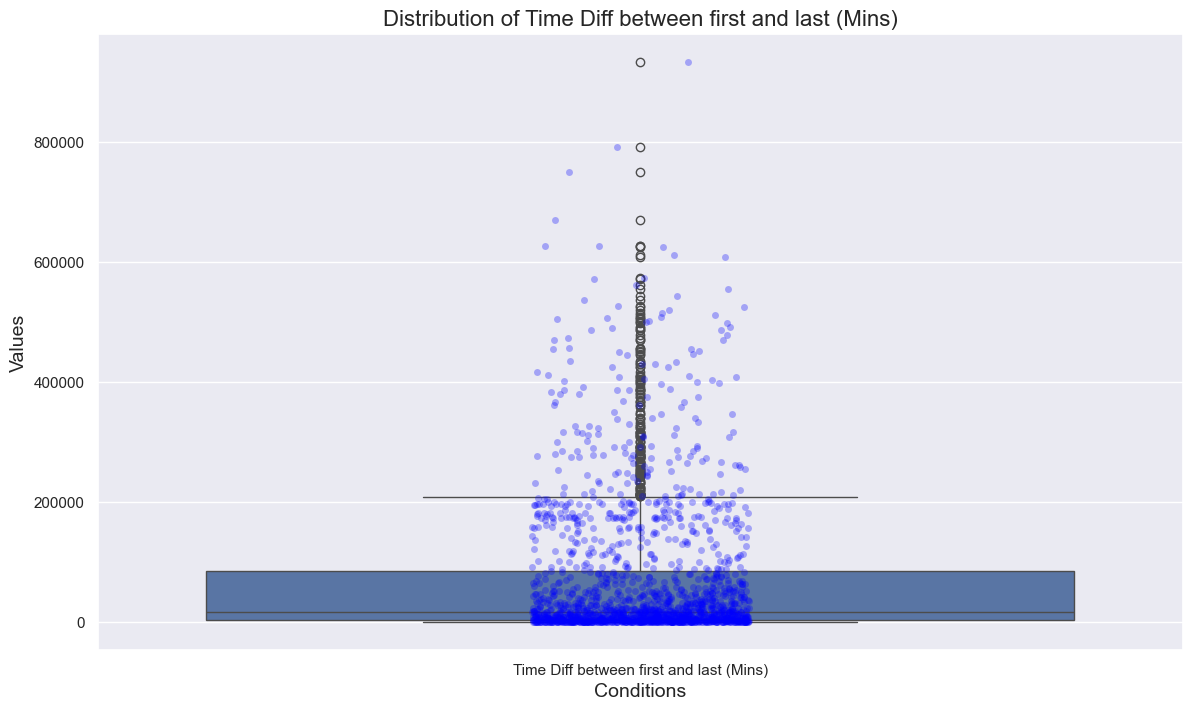

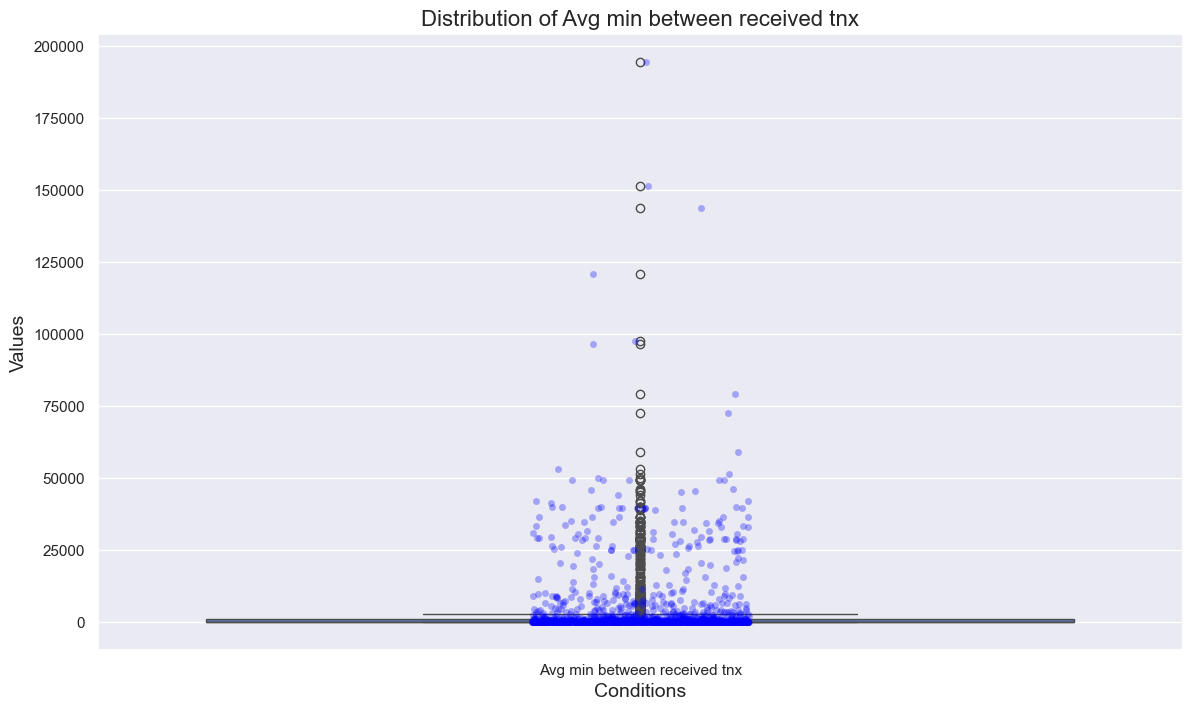

In [92]:
# Set the plotting style
sns.set(style='darkgrid')

# Create a function to draw boxplot and stripplot
def plot_boxplot_and_stripplot(data, title):
    plt.subplots(figsize=(14, 8))
    boxplot = sns.boxplot(data=data)
    stripplot = sns.stripplot(data=data, marker="o", alpha=0.3, color="blue")
    boxplot.axes.set_title(title, fontsize=16)
    boxplot.set_xlabel("Conditions", fontsize=14)
    boxplot.set_ylabel("Values", fontsize=14)
    plt.show()

# Draw boxplot and stripplot for feature 'Avg min between received tnx'
data1 = df_copy['Avg min between received tnx'][df_copy['FLAG'] == 0]
data2 = df_copy['Avg min between received tnx'][df_copy['FLAG'] == 1]
plot_boxplot_and_stripplot(data=[data1, data2], title="Distribution of Avg min between received tnx")

# Draw boxplot and stripplot for feature 'Time Diff between first and last (Mins)'
data1 = df_copy['Time Diff between first and last (Mins)'][df_copy['FLAG'] == 0]
data2 = df_copy['Time Diff between first and last (Mins)'][df_copy['FLAG'] == 1]
plot_boxplot_and_stripplot(data=[data1, data2], title="Distribution of Time Diff between first and last (Mins)")

# Draw boxplot and stripplot for feature 'Avg min between received tnx'
data1 = df_copy['Avg min between received tnx'][df_copy['FLAG'] == 0]
data2 = df_copy['Avg min between received tnx'][df_copy['FLAG'] == 1]
plot_boxplot_and_stripplot(data=[data1, data2], title="Distribution of Avg min between received tnx")

In [93]:
# Code to find and handle outliers
# In this process, we will delete some outliers, you can adjust as needed

# Find outliers in feature 'Time Diff between first and last (Mins)' and delete them
outliers_1 = df_copy[
    (df_copy['FLAG'] == 1) & 
    (df_copy['Time Diff between first and last (Mins)'] > 600000)
]
df_copy.drop(outliers_1.index, axis=0, inplace=True)

# Find outliers in feature 'Avg min between received tnx' and delete them
outliers_2 = df_copy[
    (df_copy['FLAG'] == 1) & 
    (df_copy['Avg min between received tnx'] > 60000)
]
df_copy.drop(outliers_2.index, axis=0, inplace=True)

# Find outliers in feature 'Received Tnx'
outliers_3 = df_copy[
    (df_copy['FLAG'] == 1) & 
    (df_copy['Received Tnx'] > 8000)
]

# Output the outliers found
print("Outliers found 1:")
print(outliers_1)
print()

print("Outliers found 3:")
print(outliers_3)

# Output indices of outliers in 'Avg min between received tnx' feature
print("Indices of outliers in 'Avg min between received tnx' (fraud):")
print(df_copy['Avg min between received tnx'][
    (df_copy['FLAG'] == 0) & 
    (df_copy['Avg min between received tnx'] > 400000)
].index)
print()

print("Indices of outliers in 'Avg min between received tnx' (non-fraud):")
print(df_copy['Avg min between received tnx'][
    (df_copy['FLAG'] == 1) & 
    (df_copy['Avg min between received tnx'] > 140000)
].index)

Outliers found 1:
      FLAG  Avg min between sent tnx  Avg min between received tnx  \
7788     1                   2444.91                     151554.95   
7828     1                    982.61                     120999.23   
7866     1                   8563.19                       9402.73   
8534     1                   9778.51                      53326.30   
8953     1                   5933.17                      12814.28   
9267     1                   2372.28                       6900.61   
9319     1                   1178.18                       5499.54   
9717     1                   7474.64                     194451.33   
9840     1                  37242.70                        149.56   

      Time Diff between first and last (Mins)  Sent tnx  Received Tnx  \
7788                                933778.82        10             6   
7828                                608926.62         4             5   
7866                                611848.42        44       

In [94]:
# Calculate and handle outliers for each feature
for feature in df_copy.drop('FLAG', axis=1).columns:
    # Ensure the data type of the feature is numeric
    if np.issubdtype(df_copy[feature].dtype, np.number):
        IQR = np.percentile(df_copy[feature], 75) - np.percentile(df_copy[feature], 25)
        lower_limit = np.percentile(df_copy[feature], 25) - 1.5 * IQR
        upper_limit = np.percentile(df_copy[feature], 75) + 1.5 * IQR
        
        # Calculate the number of outliers
        outliers_count = ((df_copy[feature] > upper_limit) | (df_copy[feature] < lower_limit)).sum()
        
        # Calculate the proportion of outliers
        outlier_proportion = outliers_count / df_copy.shape[0]
        
        # Set the maximum outlier proportion threshold
        max_outlier_proportion = 0.07
        
        if outlier_proportion <= max_outlier_proportion:
            print(f"The outlier proportion for feature '{feature}' is {outlier_proportion:.2%}, it will be considered.")
#             Choose further actions here, such as removing outliers from the dataset
            df_copy = df_copy[~((df_copy[feature] > upper_limit) | (df_copy[feature] < lower_limit))]

The outlier proportion for feature 'avg val sent' is 6.59%, it will be considered.
The outlier proportion for feature 'ERC20 total Ether sent contract' is 0.32%, it will be considered.
The outlier proportion for feature 'ERC20 uniq sent addr.1' is 0.00%, it will be considered.


## Removing Features With Small Correlation To The Label

In [96]:
# 1. Create a copy first (keep original logic)
dropping_corr = df_encoded.copy()

# 2. Key fix: Only select numeric columns for correlation calculation (exclude string columns)
# numeric_only=True forces processing of only numeric columns, avoiding string conversion errors
corr_matrix = df_copy.corr(numeric_only=True)

# 3. Filter columns related to FLAG (first check if FLAG exists)
if 'FLAG' not in corr_matrix.columns:
    raise ValueError("Column 'FLAG' does not exist in the DataFrame, please check the column name!")

# 4. Sort by correlation with the FLAG column
corr_decision = pd.DataFrame(corr_matrix['FLAG'].sort_values(ascending=False))

# 5. Filter features with extremely low correlation (absolute value < 0.02)
low_corr_features = corr_decision[
    (corr_decision['FLAG'] < 0.02) & (corr_decision['FLAG'] > -0.02)
].index

# 6. Remove low-correlation features (first check if features exist in dropping_corr)
# Avoid KeyError due to non-existent features
low_corr_features = [feat for feat in low_corr_features if feat in dropping_corr.columns]
dropping_encoder = dropping_corr.drop(low_corr_features, axis=1)

# 7. Output verification results
print(f"Number of features with extremely low correlation to FLAG (|r| < 0.02): {len(low_corr_features)}")
print("List of low-correlation features:", low_corr_features)
print("\nNumber of columns after removing low-correlation features:", dropping_encoder.shape[1])
print("Number of columns before removal:", dropping_corr.shape[1])

Number of features with extremely low correlation to FLAG (|r| < 0.02): 13
List of low-correlation features: ['ERC20 avg val rec', 'min value received', 'ERC20 min val rec', 'ERC20 max val rec', 'avg val received', 'ERC20 total Ether received', 'ERC20 uniq sent token name', 'Avg min between sent tnx', 'total ether balance', 'total ether received', 'Number of Created Contracts', 'max value received', 'Unique Received From Addresses']

Number of columns after removing low-correlation features: 24
Number of columns before removal: 37


# Modeling

In [97]:
df_pca

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13,PC14,PC15,PC16,PC17,PC18,PC19,PC20,PC21,FLAG
0,1.004162,-0.097451,-0.569128,0.071117,-0.030694,-0.638465,-0.885005,0.184929,0.418703,1.662230,0.533111,-0.200767,-0.211758,0.599082,-0.107712,-0.188209,-0.574507,-0.651393,1.907526,0.132751,-1.199583,0.0
1,1.104471,-0.081828,-1.204663,0.139555,-0.098832,-0.522601,-1.525271,0.199687,-0.195468,4.009561,2.617492,4.858436,-5.226034,5.410519,1.058904,-0.374138,1.342437,0.944869,-2.063726,-0.105149,0.460839,0.0
2,1.406223,-0.106620,-0.841776,0.057820,-0.212505,0.068153,-0.492720,0.105805,-0.002810,0.472786,0.180680,-0.550981,-0.316336,0.316690,0.019829,-0.359620,-0.263406,-0.445385,0.077710,0.035084,0.095890,0.0
3,9.429552,-0.679747,-0.133864,-0.803650,-0.818214,-0.744022,0.681379,1.126252,3.006732,-0.121753,-3.206963,-1.689704,-0.243834,0.374418,1.024496,-2.072325,1.011681,1.243624,0.934286,0.974142,2.186794,0.0
4,-0.872356,0.025877,0.030759,-0.099458,0.189138,-0.065388,0.181284,-0.003614,-0.099450,-0.261946,-0.163222,-0.126559,-0.358878,0.376929,0.118312,0.143675,0.173412,0.057321,-0.227354,-0.018848,0.005888,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8825,-0.909020,0.028135,0.055362,-0.110408,0.214040,-0.062064,0.228784,0.002548,-0.083625,-0.449803,-0.264127,-0.339546,-0.167641,0.178986,0.064436,0.157617,0.097034,-0.001350,-0.135584,-0.017422,-0.014928,1.0
8826,-0.303209,-0.006223,-0.168694,0.052768,0.197091,-0.224861,-0.101831,-0.119981,-0.434977,-0.891800,-0.040320,2.334541,0.439348,-0.770084,-0.112574,-1.425980,-0.411766,0.036809,-0.272229,0.023571,-0.041868,1.0
8827,0.217490,-0.043865,-0.183951,0.040287,0.110172,-0.276865,-0.245738,-0.022182,-0.094080,-0.438504,-0.108790,1.166453,0.317278,-0.478924,-0.110222,-0.957291,-0.505002,-0.280524,0.142409,0.029377,-0.234853,1.0
8828,-0.916908,0.028760,0.054962,-0.108300,0.209157,-0.058053,0.231269,0.002775,-0.085048,-0.463897,-0.268944,-0.339374,-0.163409,0.183211,0.069063,0.158406,0.099703,-0.000709,-0.153099,-0.018739,-0.005732,1.0


In [98]:
# Output the count of each label
print("Counts of each label:\n", df_pca['FLAG'].value_counts())

# Check for rows with undetermined fraud status
print("Number of rows with undetermined fraud status:", df_pca['FLAG'].isnull().sum())

# Remove rows with undetermined fraud status
df_pca_cleaned = df_encoded_cleaned.dropna(subset=['FLAG'])

# Output the counts of each label after removing rows with undetermined fraud status
print("Counts of each label after removing rows with undetermined fraud status:\n", df_pca_cleaned['FLAG'].value_counts())

Counts of each label:
 FLAG
0.0    7639
1.0     879
Name: count, dtype: int64
Number of rows with undetermined fraud status: 312
Counts of each label after removing rows with undetermined fraud status:
 FLAG
0    7220
1    1610
Name: count, dtype: int64


              precision    recall  f1-score   support

           0       0.90      0.99      0.94      2179
           1       0.92      0.49      0.64       470

    accuracy                           0.90      2649
   macro avg       0.91      0.74      0.79      2649
weighted avg       0.90      0.90      0.89      2649



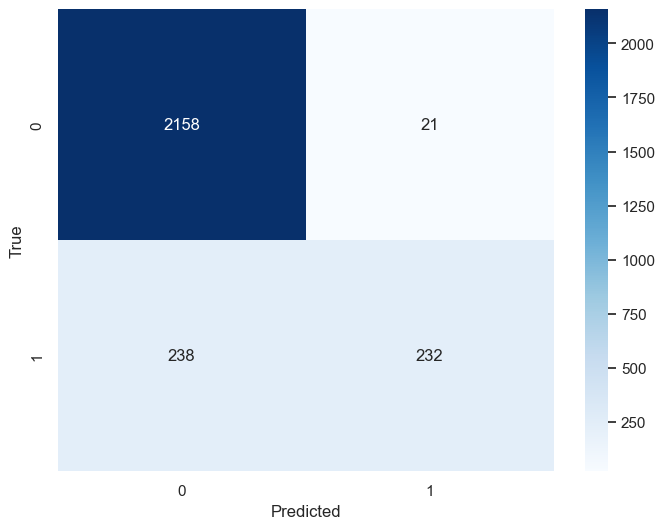

In [99]:
# Set style
sns.set(style='white')

# Prepare data
X = df_pca_cleaned.drop(['FLAG'], axis=1)
Y = df_pca_cleaned['FLAG']
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.3, random_state=42)

# Feature scaling (optional, decide whether scaling is needed)
scaler = MinMaxScaler(feature_range=(0, 1))
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Create logistic regression model
log_model = LogisticRegression(max_iter=10000, C=1.0, penalty='l2', solver='liblinear', class_weight=None)
log_model.fit(X_train_scaled, y_train)
y_pred = log_model.predict(X_test_scaled)

# Output classification report
print(classification_report(y_test, y_pred))

# Plot confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

In [100]:
!pip install xgboost


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


              precision    recall  f1-score   support

           0       0.96      0.99      0.98      2179
           1       0.97      0.81      0.89       470

    accuracy                           0.96      2649
   macro avg       0.97      0.90      0.93      2649
weighted avg       0.96      0.96      0.96      2649



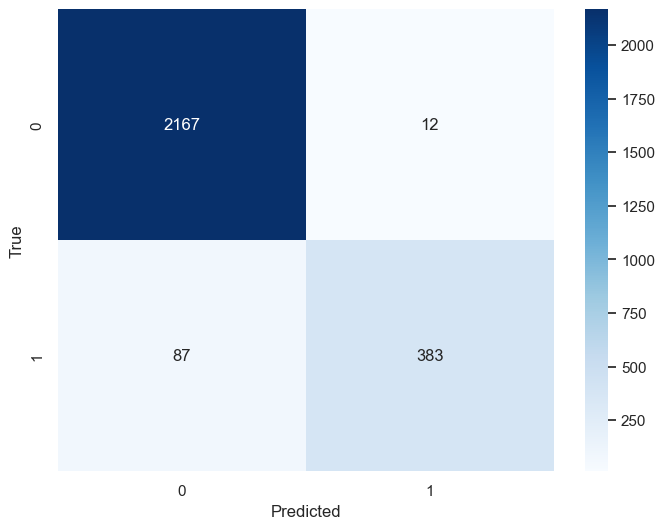

In [101]:
import xgboost as xgb

# Set style
sns.set(style='white')

# Prepare data
X = df_pca_cleaned.drop(['FLAG'], axis=1)
Y = df_pca_cleaned['FLAG']
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.3, random_state=42)

# Create XGBoost classifier model
xgb_model = xgb.XGBClassifier(
    n_estimators=100, learning_rate=0.1, max_depth=3,
    objective='binary:logistic', random_state=42
)

# Train and predict using the model
xgb_model.fit(X_train, y_train)
y_pred = xgb_model.predict(X_test)

# Output classification report
print(classification_report(y_test, y_pred))

# Plot confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

              precision    recall  f1-score   support

           0       0.95      1.00      0.97      2179
           1       0.99      0.76      0.86       470

    accuracy                           0.96      2649
   macro avg       0.97      0.88      0.92      2649
weighted avg       0.96      0.96      0.95      2649



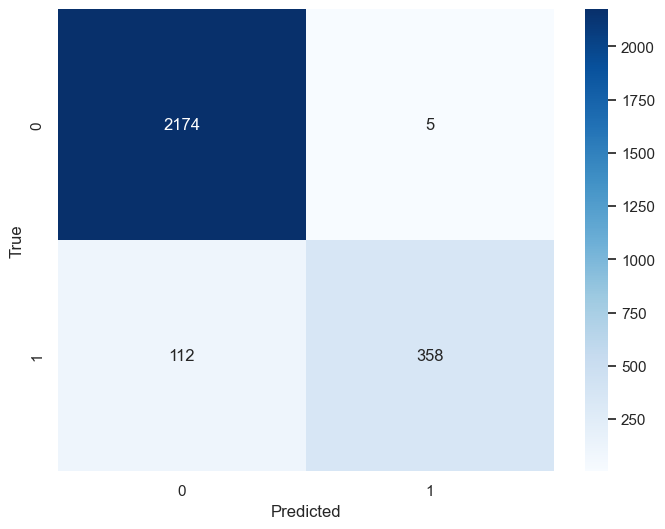

In [102]:
from sklearn.ensemble import RandomForestClassifier

# Set style
sns.set(style='white')

# Prepare data
X = df_pca_cleaned.drop(['FLAG'], axis=1)
Y = df_pca_cleaned['FLAG']
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.3, random_state=42)

# Create Random Forest classifier model
rf_model = RandomForestClassifier(
    n_estimators=100, max_depth=10, random_state=42
)

# Train and predict using the model
rf_model.fit(X_train, y_train)
y_pred = rf_model.predict(X_test)

# Output classification report
print(classification_report(y_test, y_pred))

# Plot confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

              precision    recall  f1-score   support

           0       0.91      0.99      0.95      2179
           1       0.93      0.54      0.68       470

    accuracy                           0.91      2649
   macro avg       0.92      0.76      0.81      2649
weighted avg       0.91      0.91      0.90      2649



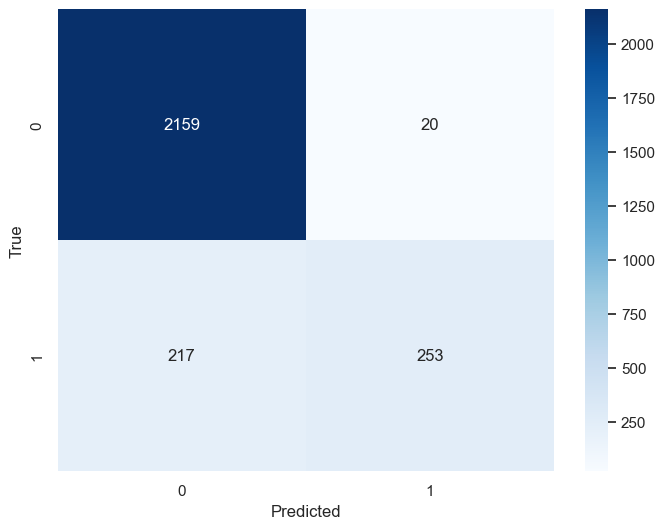

In [103]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Set style
sns.set(style='white')

# Prepare data
X = df_pca_cleaned.drop(['FLAG'], axis=1)
Y = df_pca_cleaned['FLAG']
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.3, random_state=42)

# Feature scaling
scaler = MinMaxScaler(feature_range=(0, 1))
scaler.fit(X_train)
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Create Support Vector Machine classifier model
svm_model = SVC(C=10, gamma=1, kernel='rbf', random_state=42)

# Train and predict using the model
svm_model.fit(X_train_scaled, y_train)
y_pred = svm_model.predict(X_test_scaled)

# Output classification report
print(classification_report(y_test, y_pred))

# Plot confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

              precision    recall  f1-score   support

           0       0.96      0.17      0.29      2179
           1       0.20      0.97      0.33       470

    accuracy                           0.31      2649
   macro avg       0.58      0.57      0.31      2649
weighted avg       0.83      0.31      0.30      2649



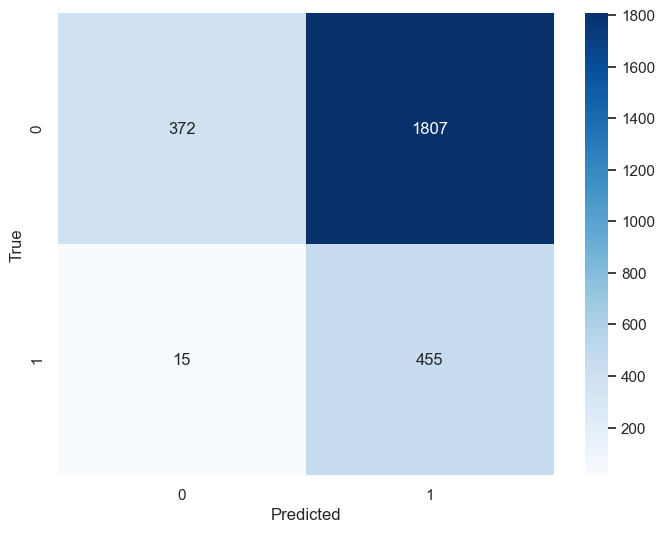

In [104]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Set style
sns.set(style='white')

# Prepare data
X = df_pca_cleaned.drop(['FLAG'], axis=1)
Y = df_pca_cleaned['FLAG']
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.3, random_state=42)

# Feature scaling
scaler = MinMaxScaler(feature_range=(0, 1))
scaler.fit(X_train)
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Create Naive Bayes classifier model
nb_model = GaussianNB()

# Train and predict using the model
nb_model.fit(X_train_scaled, y_train)
y_pred = nb_model.predict(X_test_scaled)

# Output classification report
print(classification_report(y_test, y_pred))

# Plot confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

              precision    recall  f1-score   support

           0       0.94      0.99      0.96      2284
           1       0.92      0.73      0.81       505

    accuracy                           0.94      2789
   macro avg       0.93      0.86      0.89      2789
weighted avg       0.94      0.94      0.94      2789



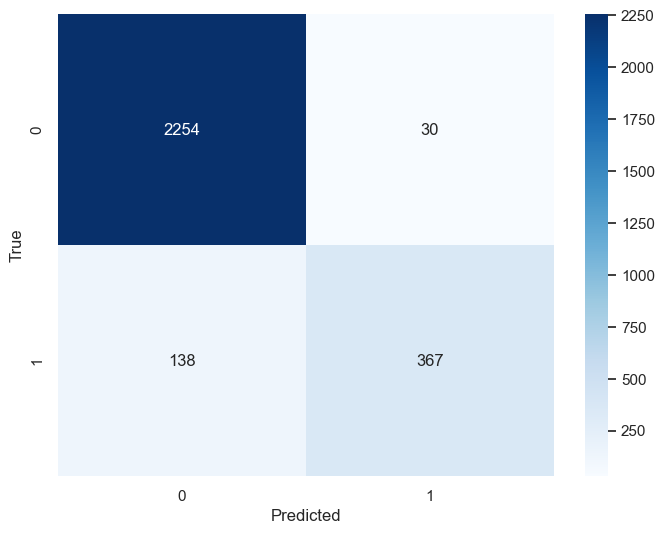

In [105]:
# Easily amplify the weights of misclassified samples
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Set style
sns.set(style='white')

# Prepare data
X = dropping_corr.drop(['FLAG'], axis=1)
Y = dropping_corr['FLAG']
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.3, random_state=42)

# Feature scaling
scaler = MinMaxScaler(feature_range=(0, 1))
scaler.fit(X_train)
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Create AdaBoost classifier model
adaboost_model = AdaBoostClassifier(n_estimators=50, random_state=42)

# Train the model
adaboost_model.fit(X_train_scaled, y_train)

# Predict using the model
y_pred = adaboost_model.predict(X_test_scaled)

# Output classification report
print(classification_report(y_test, y_pred))

# Plot confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

# PCA

# Conclusion

In this notebook, we wanted to make a classification, and to understand which Ethereum transaction is a 
fraud, and which is not. We did EDA, we chose which attributes we should use to predict the model, and 
which features we should avoid. We had to deal with outliers in the data set, and we had to be aware of 
correlation issues, that can make us decide to avoid some features, that are highly correlated with others. 
Then we used 3 different models – Logistic Regression, SVM, and Random Forest.
The Random Forest Model did the best work for us. to conclude, we think that we answer the question 
well, and we could predict fraudulent transactions. For future work, we suggest adding the volatility of 
Ethereum to the consideration, for example in times there is the high volatility of the crypto, it may be 
the time that the fraudulent transactions are increasing.